<a href="https://colab.research.google.com/github/daf01-web/Mineria-de-Datos/blob/main/naming_colors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Naming colors

If you are shown random colors evenly spaced across the color spectrum, what percentage of those colors would the average person name red? What about green?

English speakers in the United States were shown 80 color chips in random order in controlled lighting condtions. These 80 colors are evenly spaced across the standard Munsell array of colors. The participants were told: "There are 11 choices: black, white, red, green, blue, purple, brown, yellow, orange, pink, gray. Choose the closest color word".

This study was then repeated with Bolivian-Spanish speakers in Bolivia and Tsimane' speakers from the Amazon.

The dataset `munsell-array-fixed-choice.csv` shows the most common name in each language for each color chip.

In [2]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'munsell-array-fixed-choice.csv'.

from google.colab import files
uploaded = files.upload()

Saving munsell-array-fixed-choice.csv to munsell-array-fixed-choice (1).csv


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("munsell-array-fixed-choice.csv")
df.head()

,grid,x,y,munsell_code,tile_hex,english_color,spanish_color,tsimane_color,spanish,tsimane
0,B1,1,7,5R8/6,#fbb6b0,pink,pink,yellow,rosada (pink),chamus (yellow)
1,D1,1,5,5R6/12,#eb6a68,pink,pink,red,rosada (pink),jainas (red)
2,F1,1,3,5R4/14,#bb1933,red,red,red,rojo (red),jainas (red)
3,H1,1,1,5R2/8,#610d25,red,red,brown,rojo (red),cafedyeisi (brown)
4,A2,2,8,10R9/2,#f2ded8,pink,white,white,blanco (white),jaibas (white)


The function below plots the 80 evenly spaced colors that each study participant was shown in random order.

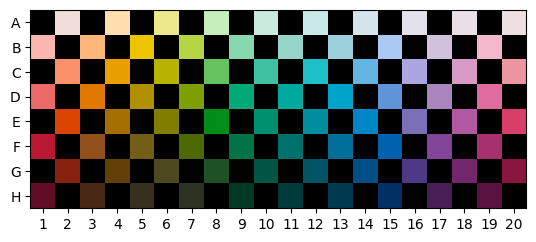

In [4]:
def plot_colors(color_column):
    fig, ax = plt.subplots()
    for idx, row in df.iterrows():
        ax.add_patch(plt.Rectangle((row['x'] - 0.5, row['y'] - 0.5), 1, 1, color=row[color_column], linewidth=0))

    ax.set_xlim(0.5, 20.5)
    ax.set_ylim(0.5, 8.5)
    ax.set_aspect('equal')
    ax.set_facecolor('black')
    ax.set_xticks(range(1, 21))
    ax.set_yticks(range(1, 9), ['H', 'G', 'F', 'E', 'D', 'C', 'B', 'A'])

plot_colors('tile_hex')

We can also use this function to plot the most common name in each language for each color chip.

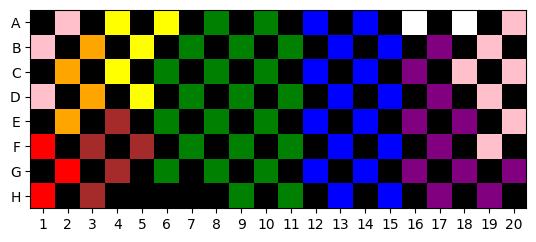

In [5]:
# Also try 'spanish_color' and 'tsimane_color'
plot_colors('english_color')

### Project Ideas:

- For each language, calculate what percentage of chips are named each color. Return dataframes for each language.

- Create a horizontal bar plot for each language. Each bar represents a color name and the length encodes the percentage of chips that are named that color.

- Is there a correlation between languages? Create scatter plots.
	- Hint: the x-axis could be the percentage of chips for English speakers and the y-axis could be the percentage of chips for Tsimane speakers and each data point represents a color name.

	- You might need to `merge` dataframes.


In [ ]:
# YOUR CODE HERE (add more cells as needed)

In [8]:
df_en = df['english_color'].value_counts(normalize=True).mul(100).reset_index()
df_en.columns = ['color', 'percentage']
display(df_en.head())

df_es = df['spanish_color'].value_counts(normalize=True).mul(100).reset_index()
df_es.columns = ['color', 'percentage']
display(df_es.head())

df_ts = df['tsimane_color'].value_counts(normalize=True).mul(100).reset_index()
df_ts.columns = ['color', 'percentage']
display(df_ts.head())

,color,percentage
0,green,27.50
1,blue,20.00
2,purple,13.75
3,pink,12.50
4,yellow,6.25


,color,percentage
0,green,27.50
1,lightblue,13.75
2,purple,13.75
3,pink,10.00
4,white,7.50


,color,percentage
0,green,25.00
1,blue,15.00
2,yellow,13.75
3,purple,12.50
4,white,11.25


/tmp/ipykernel_214/2159283733.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='percentage', y='color', data=dataframe, palette='viridis')


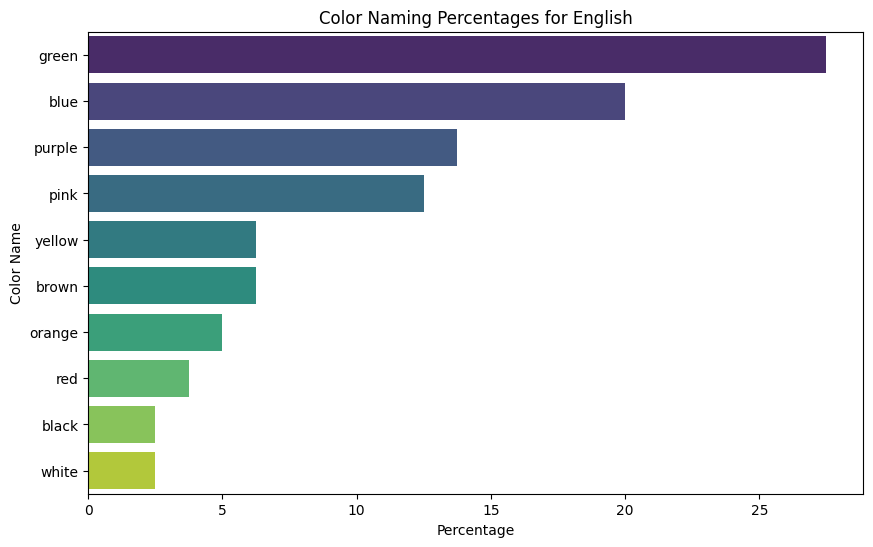

/tmp/ipykernel_214/2159283733.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='percentage', y='color', data=dataframe, palette='viridis')


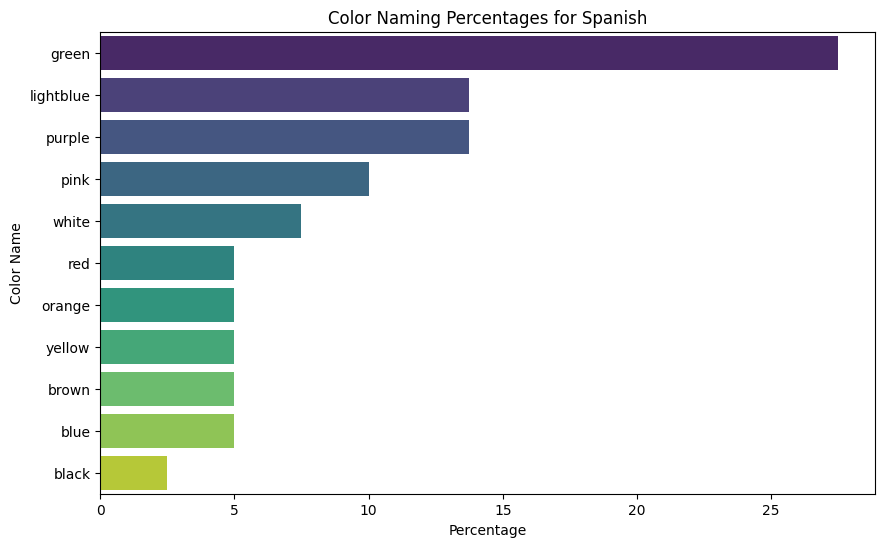

/tmp/ipykernel_214/2159283733.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='percentage', y='color', data=dataframe, palette='viridis')


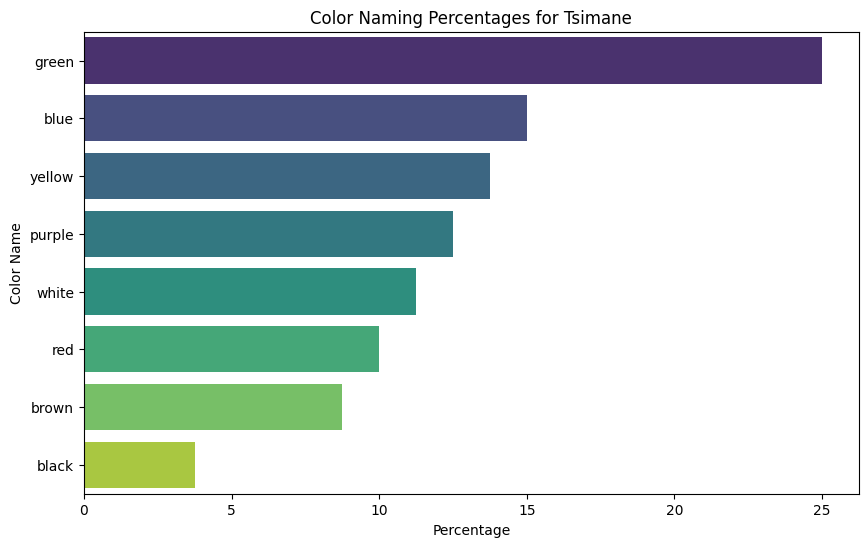

In [9]:
import seaborn as sns

def plot_language_percentages(dataframe, language_name):
    plt.figure(figsize=(10, 6))
    sns.barplot(x='percentage', y='color', data=dataframe, palette='viridis')
    plt.title(f'Color Naming Percentages for {language_name}')
    plt.xlabel('Percentage')
    plt.ylabel('Color Name')
    plt.show()

# Call the function for each language
plot_language_percentages(df_en, 'English')
plot_language_percentages(df_es, 'Spanish')
plot_language_percentages(df_ts, 'Tsimane')

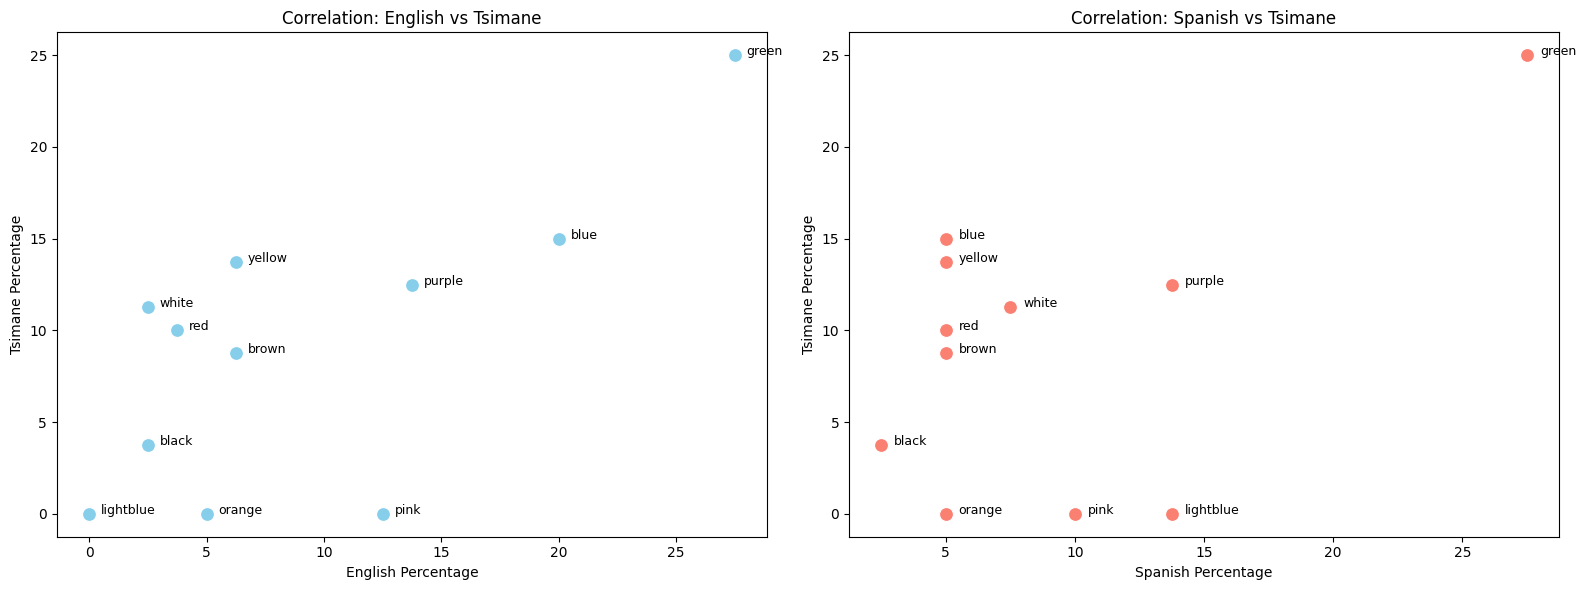

Correlación de Pearson (EN vs TS): 0.7057953922022799
Correlación de Pearson (ES vs TS): 0.5061250062736189


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Unir (Merge) los dataframes para comparar
# Combinamos Inglés y Tsimane' primero
df_corr = pd.merge(df_en, df_ts, on='color', how='outer', suffixes=('_en', '_ts')).fillna(0)

# Combinamos el resultado con Español
df_corr = pd.merge(df_corr, df_es, on='color', how='outer').fillna(0)
df_corr = df_corr.rename(columns={'percentage': 'percentage_es'})

# Crear los Scatter Plots de comparación
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Comparación 1: Inglés vs Tsimane'
sns.scatterplot(data=df_corr, x='percentage_en', y='percentage_ts', ax=ax1, s=100, color='skyblue')
ax1.set_title('Correlation: English vs Tsimane')
ax1.set_xlabel('English Percentage')
ax1.set_ylabel('Tsimane Percentage')
for i in range(df_corr.shape[0]):
    ax1.text(df_corr.percentage_en[i]+0.5, df_corr.percentage_ts[i], df_corr.color[i], fontsize=9)

# Comparación 2: Español vs Tsimane'
sns.scatterplot(data=df_corr, x='percentage_es', y='percentage_ts', ax=ax2, s=100, color='salmon')
ax2.set_title('Correlation: Spanish vs Tsimane')
ax2.set_xlabel('Spanish Percentage')
ax2.set_ylabel('Tsimane Percentage')
for i in range(df_corr.shape[0]):
    ax2.text(df_corr.percentage_es[i]+0.5, df_corr.percentage_ts[i], df_corr.color[i], fontsize=9)

plt.tight_layout()
plt.show()

# Opcional: Calcular el coeficiente de correlación de Pearson
print("Correlación de Pearson (EN vs TS):", df_corr['percentage_en'].corr(df_corr['percentage_ts']))
print("Correlación de Pearson (ES vs TS):", df_corr['percentage_es'].corr(df_corr['percentage_ts']))